# Volume-Constrained Final Operational DOE Campaign

This notebook documents the executable campaign selected after adding the reactor-volume constraint.

Use this notebook as the visual companion to the CSV protocol:

- `full_liquid_sample`: 50 mL. Ethanol and aromas are sampled together.
- `small_liquid_sample`: 8 mL. No ethanol/aromas; intended for biomass, sugars, YAN/PAN/NH4, glycerol, pyruvate, acetaldehyde, and acetate.
- DO is measured, not manipulated.
- CO2 is assumed online and therefore not represented as a destructive liquid sample.
- Terminal condensate retrieval is a final trap sample, not a repeated online aroma measurement.

The active design is the volume-constrained campaign in `results/final_operational_doe_volume_constrained`.
The older unconstrained DOE is retained only as a reference and should not be used as the lab protocol.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

ROOT = Path.cwd()
if (ROOT / "fermentation_model").exists():
    FM = ROOT / "fermentation_model"
else:
    FM = ROOT

if str(FM) not in sys.path:
    sys.path.insert(0, str(FM))

import run_final_operational_doe_volume_constrained as vc
import run_final_operational_doe_v2 as final
import run_new_must_glycerol_estimability_doe as base
import run_secondary_joint_campaign_doe as joint

RESULTS = FM / "results" / "final_operational_doe_volume_constrained"
PLOT_DIR = FM / "results" / "vc_doe_nb_plots"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

protocol = pd.read_csv(RESULTS / "campaign_protocol.csv")
schedule = pd.read_csv(RESULTS / "operational_schedule.csv", parse_dates=["datetime"])
volume = pd.read_csv(RESULTS / "volume_audit.csv")
stock = pd.read_csv(RESULTS / "stock_concentration_assumptions.csv")
policy_summary = pd.read_csv(RESULTS / "policy_summary.csv")
post_estimability = pd.read_csv(RESULTS / "post_campaign_estimability.csv")

theta = final.load_theta_final()
data = base.load_normalized_data()
designs = final.candidate_library(data)
POLICY = str(policy_summary.iloc[0]["policy"])
POLICY

'full14_small6'

## Design Selection Summary

The selected policy is compared against more conservative full-sample schedules. Scores are computed from the extended FIM under the volume-constrained observation model, so they should only be compared within this table.

In [2]:
cols = [
    "policy",
    "campaign_logdet",
    "campaign_trace_inv",
    "new_param_mean_var_reduction",
    "new_param_worst_var_reduction",
]
display(policy_summary[cols])

,policy,campaign_logdet,campaign_trace_inv,new_param_mean_var_reduction,new_param_worst_var_reduction
0,full14_small6,187.107695,2.224975,0.984270,0.935417
1,full12_small8,181.977621,2.862439,0.983203,0.930912
2,full10_small10,179.137234,2.959083,0.981700,0.924231


## Campaign Protocol

One row is one fermentation. Lots are groups of three parallel reactors.

In [3]:
display(protocol)

,campaign_order,lot,start_datetime,candidate,medium,family,horizon_h,temperature_segments,initial_N_mg_l,initial_G_g_l,initial_F_g_l,initial_E_g_l,initial_X_kg_m3,full_samples,small_samples,planned_sample_volume_ml,rationale
0,1,1,2026-06-15 08:00:00,synthetic_lit_SM410_18C_highN_ester,synthetic,literature_nitrogen_high,216.0,"18, 18, 18, 18",410.00,115.000,115.000,0.0,0.420525,14,6,748.0,Literature SM410-like high YAN tests ester cap...
1,2,1,2026-06-15 08:00:00,synthetic_high_biomass_low_N_maintenance,synthetic,maintenance,216.0,"16, 18, 20, 18",30.00,75.000,75.000,10.0,2.000000,14,6,748.0,High biomass with low N creates low-growth sug...
2,3,1,2026-06-15 08:00:00,synthetic_fructose_rich_glucose_pulse,synthetic,sugar_separation,216.0,"17, 20, 23, 20",240.00,35.000,155.000,0.0,0.420525,14,6,748.0,Fructose-rich run probes iG and fructose kinet...
3,4,2,2026-06-29 08:00:00,synthetic_glucose_rich_fructose_pulse,synthetic,sugar_separation,216.0,"17, 20, 23, 20",240.00,155.000,35.000,0.0,0.420525,14,6,748.0,High glucose plus fructose pulse separates glu...
4,5,2,2026-06-29 08:00:00,synthetic_lit_SM410_24C_highN_strip,synthetic,literature_temp_strip,168.0,"20, 24, 24, 20",410.00,125.000,125.000,0.0,0.420525,12,4,632.0,High YAN plus warm high-rate fermentation exci...
5,6,2,2026-06-29 08:00:00,synthetic_viable_biomass_step,synthetic,biomass_input,216.0,"18, 22, 22, 18",220.00,90.000,90.000,0.0,0.300000,14,6,748.0,Known viable biomass addition tests rate propo...
6,7,3,2026-07-13 08:00:00,synthetic_high_sugar_reference,synthetic,synthetic_baseline,216.0,"18, 20, 20, 18",220.50,124.465,117.685,0.0,0.420525,14,6,748.0,Synthetic high-sugar operating point close to ...
7,8,3,2026-07-13 08:00:00,natural_glucose_pulse_after_growth,natural,natural_sugar_pulse,216.0,"18, 20, 22, 19",229.12,76.210,76.670,0.0,0.393900,14,6,748.0,Natural must with glucose perturbation to test...
8,9,3,2026-07-13 08:00:00,synthetic_fast_CO2_aroma_strip_highN,synthetic,co2_aroma_loss,168.0,"20, 24, 24, 20",300.00,135.000,135.000,0.0,0.420525,12,4,632.0,High-rate fermentation excites CO2 stripping a...


## Volume And Stock Audit

The design keeps final reactor volume above the 1100 mL safety target after destructive samples and stock additions.

Stock pulse volume is computed as:

```text
V_stock = target_dose * current_reactor_volume / stock_concentration
```

In [4]:
display(volume)
display(stock)

,campaign_order,candidate,initial_volume_ml,final_volume_ml,net_volume_removed_ml,below_min_final_volume,max_single_pulse_volume_ml
0,1,synthetic_lit_SM410_18C_highN_ester,2000.0,1252.000000,748.000000,False,0.000000
1,2,synthetic_high_biomass_low_N_maintenance,2000.0,1371.088108,628.911892,False,61.928571
2,3,synthetic_fructose_rich_glucose_pulse,2000.0,1337.714250,662.285750,False,81.129250
3,4,synthetic_glucose_rich_fructose_pulse,2000.0,1337.714250,662.285750,False,81.129250
4,5,synthetic_lit_SM410_24C_highN_strip,2000.0,1368.000000,632.000000,False,0.000000
5,6,synthetic_viable_biomass_step,2000.0,1273.810850,726.189150,False,17.225850
6,7,synthetic_high_sugar_reference,2000.0,1256.585000,743.415000,False,4.585000
7,8,natural_glucose_pulse_after_growth,2000.0,1340.788550,659.211450,False,86.037550
8,9,synthetic_fast_CO2_aroma_strip_highN,2000.0,1368.000000,632.000000,False,0.000000


,channel,stock_concentration,unit,max_single_pulse_ml_target,comment
0,N,20.0,mg_N_per_mL,15.0,20 mg YAN-N/mL gives 5-6 mL for a 50-60 mg/L p...
1,G,700.0,g_per_L,125.0,700 g/L is concentrated and viscous but keeps ...
2,F,700.0,g_per_L,125.0,Use same concentration as glucose because fruc...
3,E,789.0,g_per_L,80.0,Pure ethanol basis; not used in selected hybri...
4,X,100.0,g_dry_biomass_per_L,35.0,Dry-biomass-equivalent concentrated slurry; ve...


## Daily Workload

This table is useful for lab staffing and analytical capacity. It counts events at the lot level, so three parallel reactors can produce up to three simultaneous actions.

In [5]:
work = schedule.copy()
work["date"] = work["datetime"].dt.date
daily = work.groupby(["lot", "date", "event"]).size().unstack(fill_value=0).reset_index()
display(daily)

event,lot,date,DO_measurement,full_liquid_sample,manual_pulse,small_liquid_sample,terminal_condensate_retrieval
0,1,2026-06-15,13,6,0,4,0
1,1,2026-06-16,12,6,1,6,0
2,1,2026-06-17,10,6,1,4,0
3,1,2026-06-18,0,6,2,4,0
4,1,2026-06-19,0,12,1,0,0
5,1,2026-06-22,0,6,0,0,0
6,1,2026-06-24,0,0,0,0,3
7,2,2026-06-29,15,6,0,6,0
8,2,2026-06-30,12,6,2,6,0
9,2,2026-07-01,8,6,1,2,0


## Complete Operational Schedule

The key event types are:

- `full_liquid_sample`: 50 mL, ethanol + aromas + full panel.
- `small_liquid_sample`: 8 mL, no ethanol/aromas.
- `manual_pulse`: stock addition.
- `DO_measurement`: oxygen observation, no oxygen control.
- `terminal_condensate_retrieval`: final condensate trap sample.

In [6]:
display(schedule)

,campaign_order,lot,candidate,event,relative_time_h,datetime,weekday,details,channel,amount,volume_ml,operational,volume_before_ml,volume_after_ml
0,1,1,synthetic_lit_SM410_18C_highN_ester,DO_measurement,0.0,2026-06-15 08:00:00,Monday,DO spot measurement; no controlled oxygen pulse,NaN,NaN,0.0,True,2000.0,2000.0
1,1,1,synthetic_lit_SM410_18C_highN_ester,DO_measurement,2.0,2026-06-15 10:00:00,Monday,DO spot measurement; no controlled oxygen pulse,NaN,NaN,0.0,True,2000.0,2000.0
2,1,1,synthetic_lit_SM410_18C_highN_ester,full_liquid_sample,2.0,2026-06-15 10:00:00,Monday,ethanol+aromas+full panel,NaN,NaN,50.0,True,2000.0,1950.0
3,1,1,synthetic_lit_SM410_18C_highN_ester,DO_measurement,4.0,2026-06-15 12:00:00,Monday,DO spot measurement; no controlled oxygen pulse,NaN,NaN,0.0,True,1950.0,1950.0
4,1,1,synthetic_lit_SM410_18C_highN_ester,small_liquid_sample,4.0,2026-06-15 12:00:00,Monday,small panel: biomass/YAN/sugars/glycerol/secon...,NaN,NaN,8.0,True,1950.0,1942.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,9,3,synthetic_fast_CO2_aroma_strip_highN,full_liquid_sample,98.0,2026-07-17 10:00:00,Friday,ethanol+aromas+full panel,NaN,NaN,50.0,True,1568.0,1518.0
296,9,3,synthetic_fast_CO2_aroma_strip_highN,full_liquid_sample,100.0,2026-07-17 12:00:00,Friday,ethanol+aromas+full panel,NaN,NaN,50.0,True,1518.0,1468.0
297,9,3,synthetic_fast_CO2_aroma_strip_highN,full_liquid_sample,102.0,2026-07-17 14:00:00,Friday,ethanol+aromas+full panel,NaN,NaN,50.0,True,1468.0,1418.0
298,9,3,synthetic_fast_CO2_aroma_strip_highN,full_liquid_sample,104.0,2026-07-17 16:00:00,Friday,ethanol+aromas+full panel,NaN,NaN,50.0,True,1418.0,1368.0


## Per-Fermentation DOE Plots

Each plot shows the actual DOE inputs and observation schedule for one selected fermentation:

1. Temperature setpoint.
2. Manual pulses.
3. Full/small/DO/terminal sampling events.
4. Reactor volume trajectory.
5. Simulated core states.
6. Simulated secondary states and CO2.
7. Simulated liquid aromas plus terminal condensate prediction.

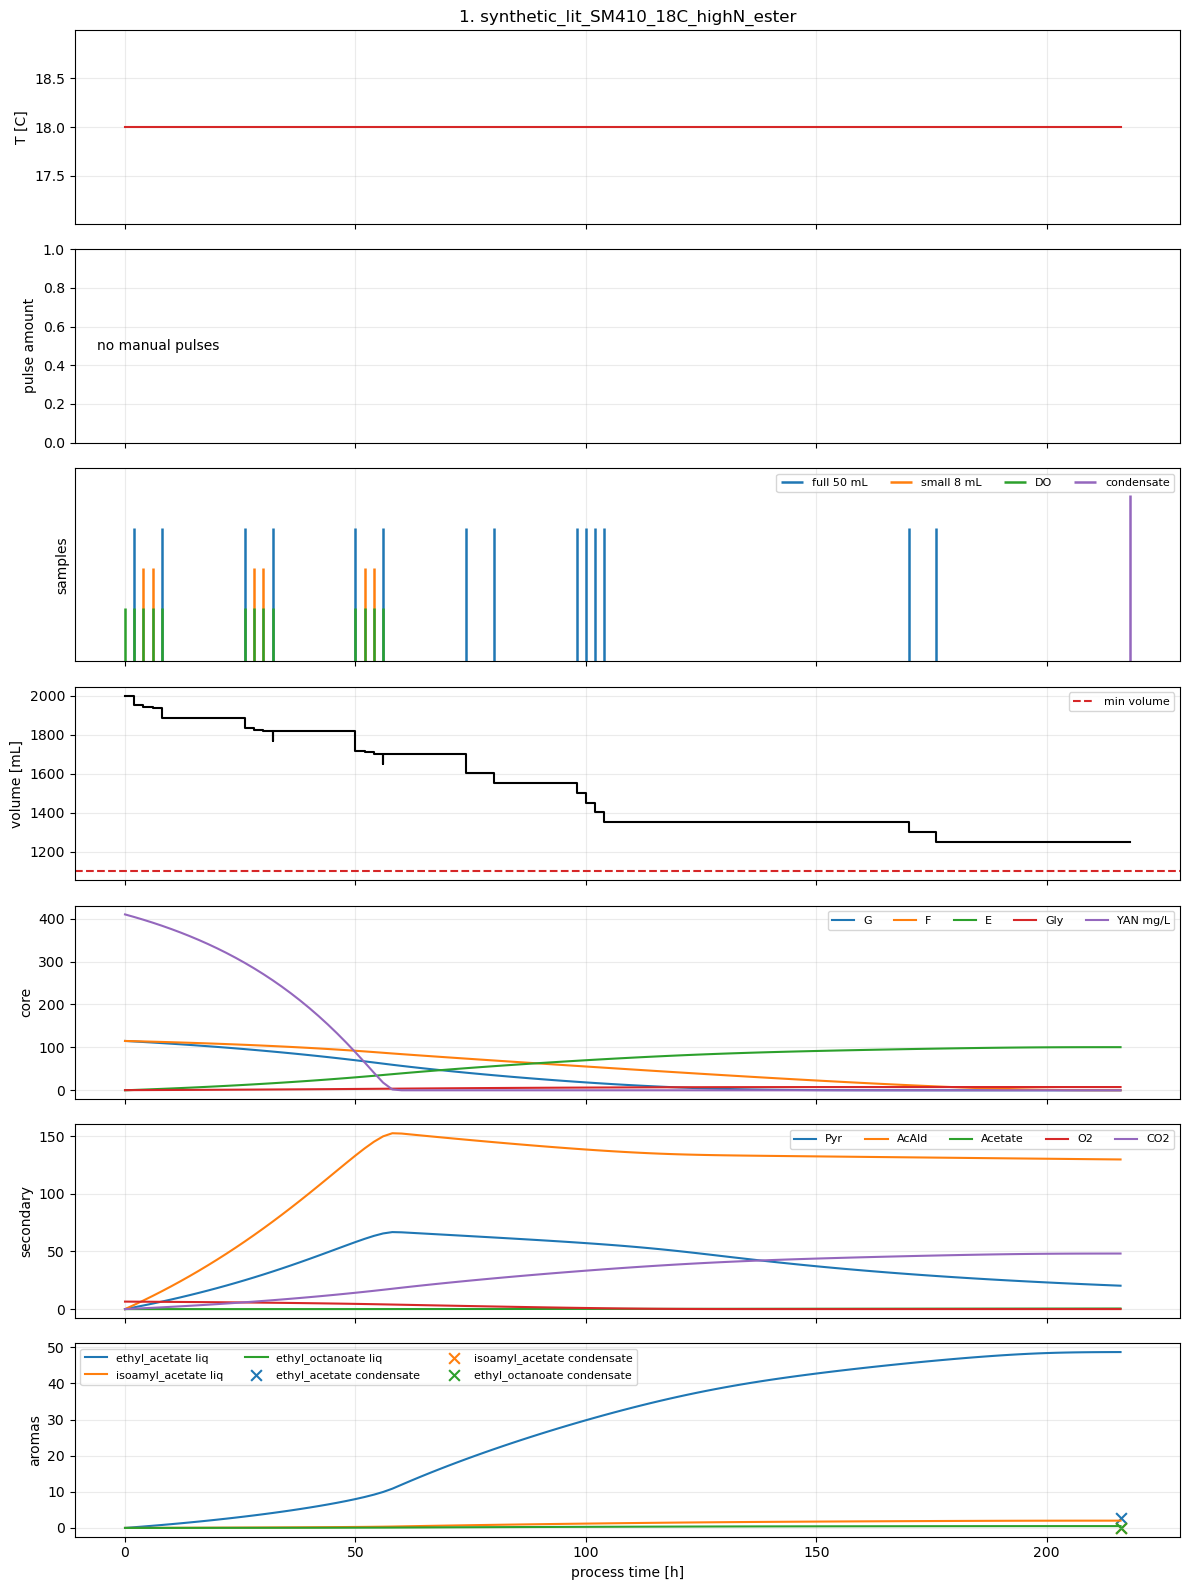

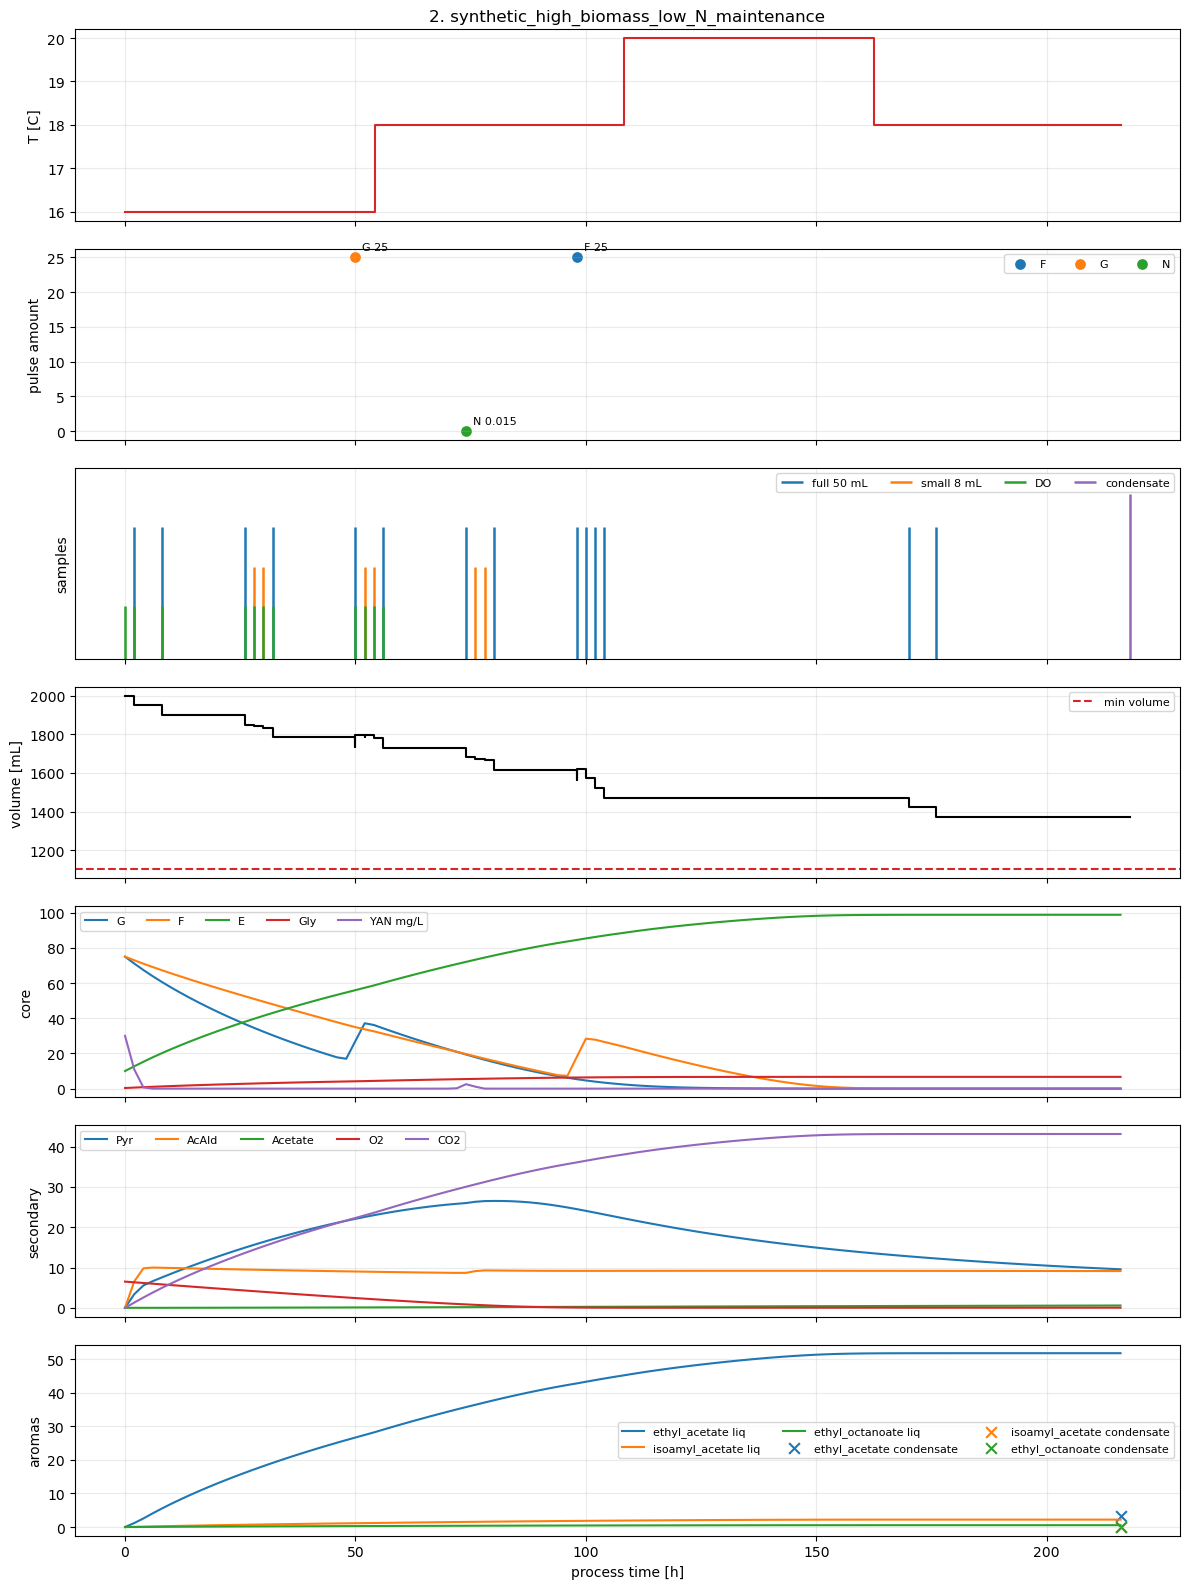

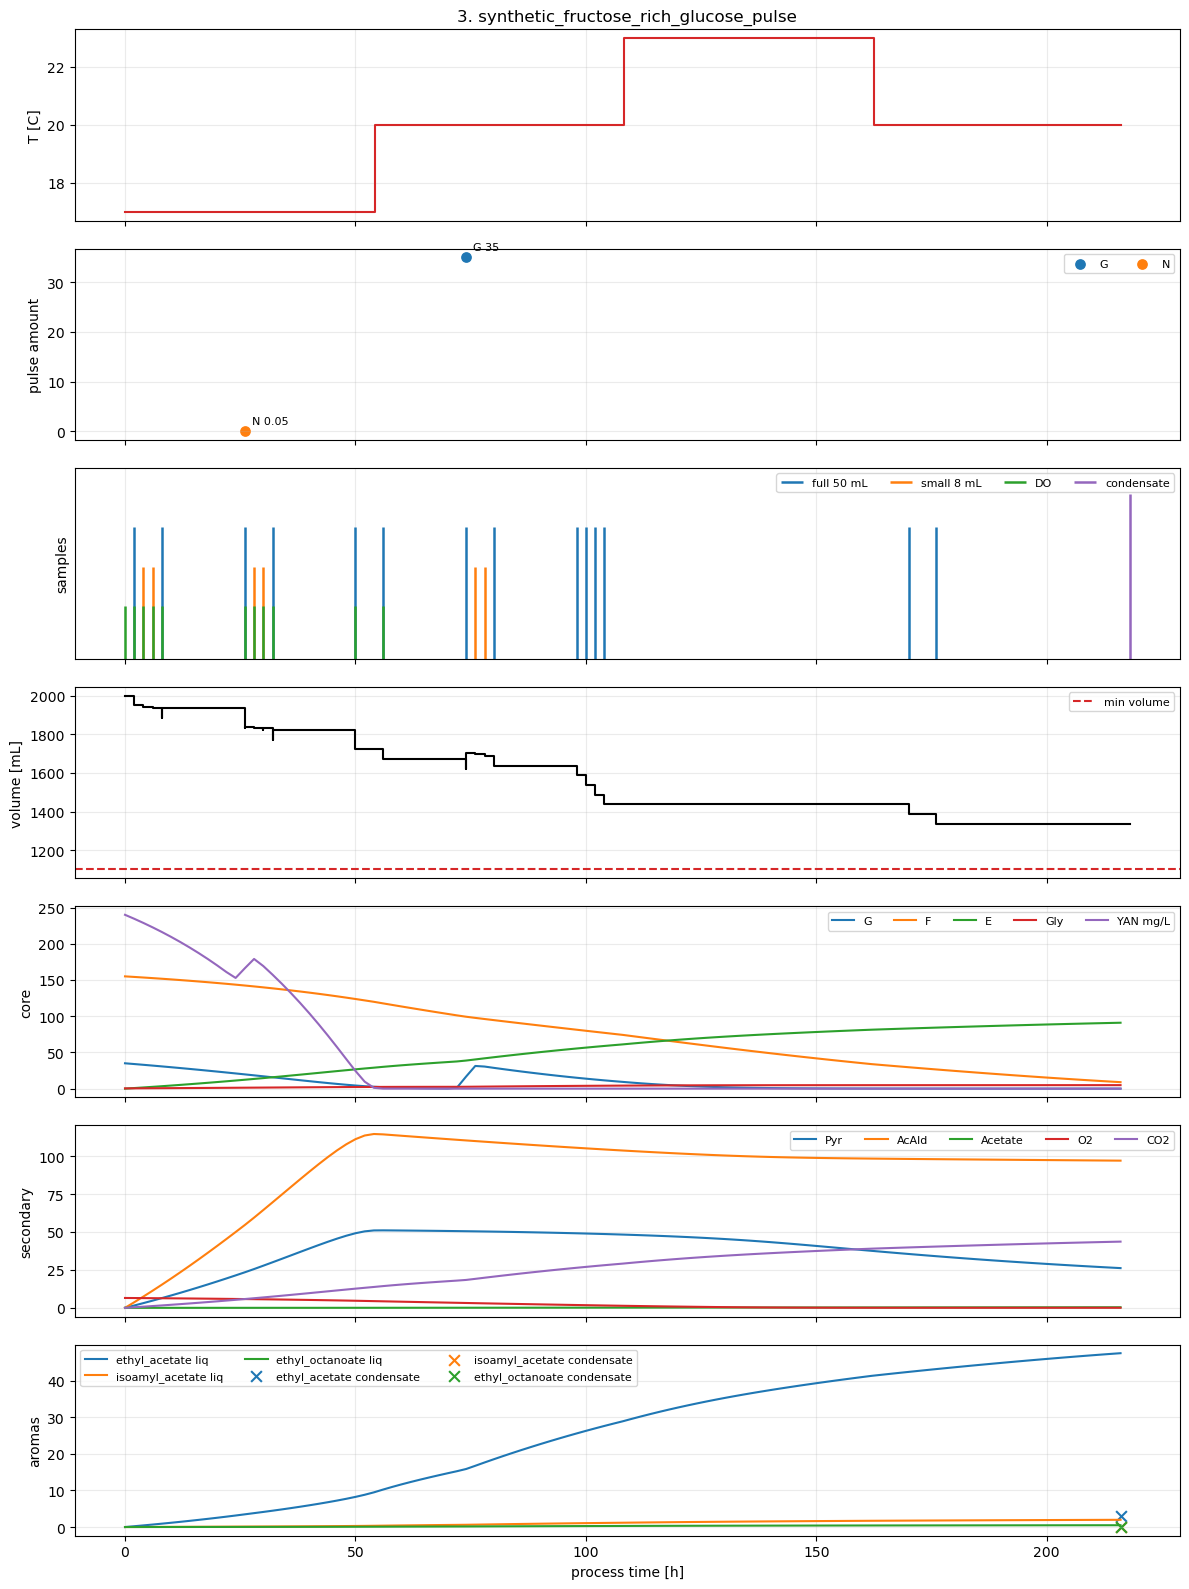

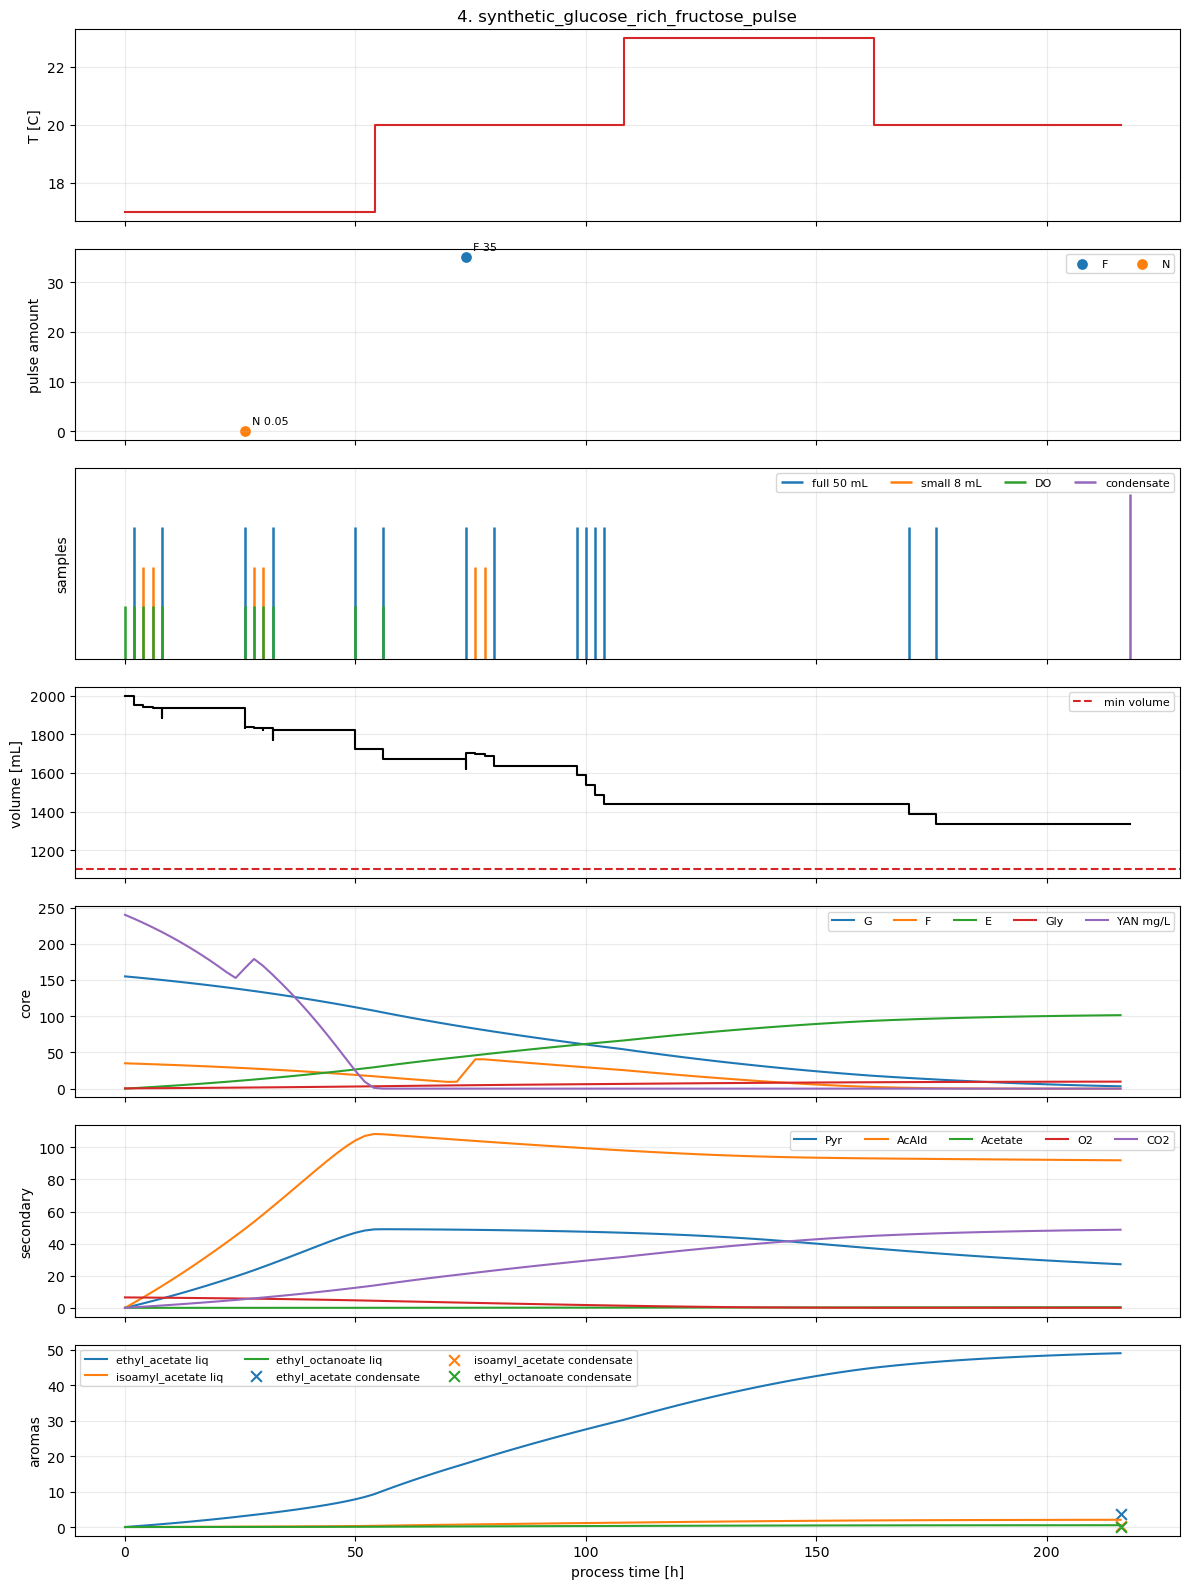

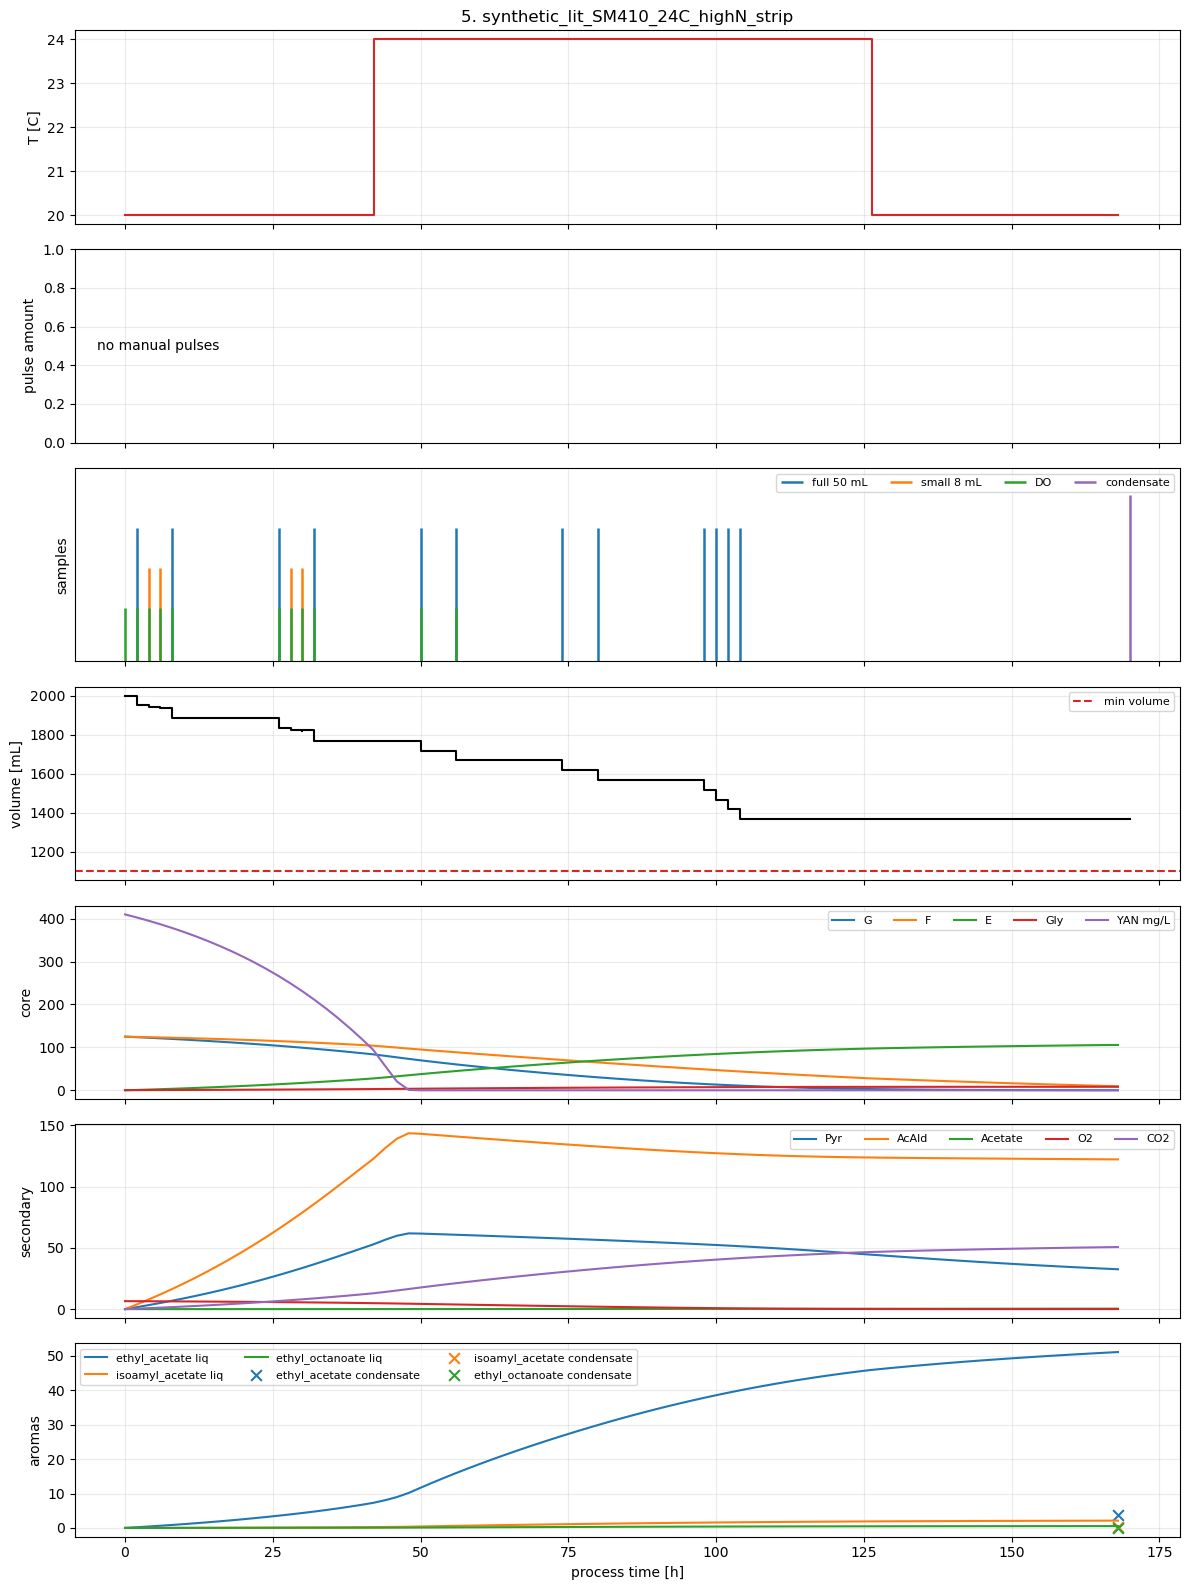

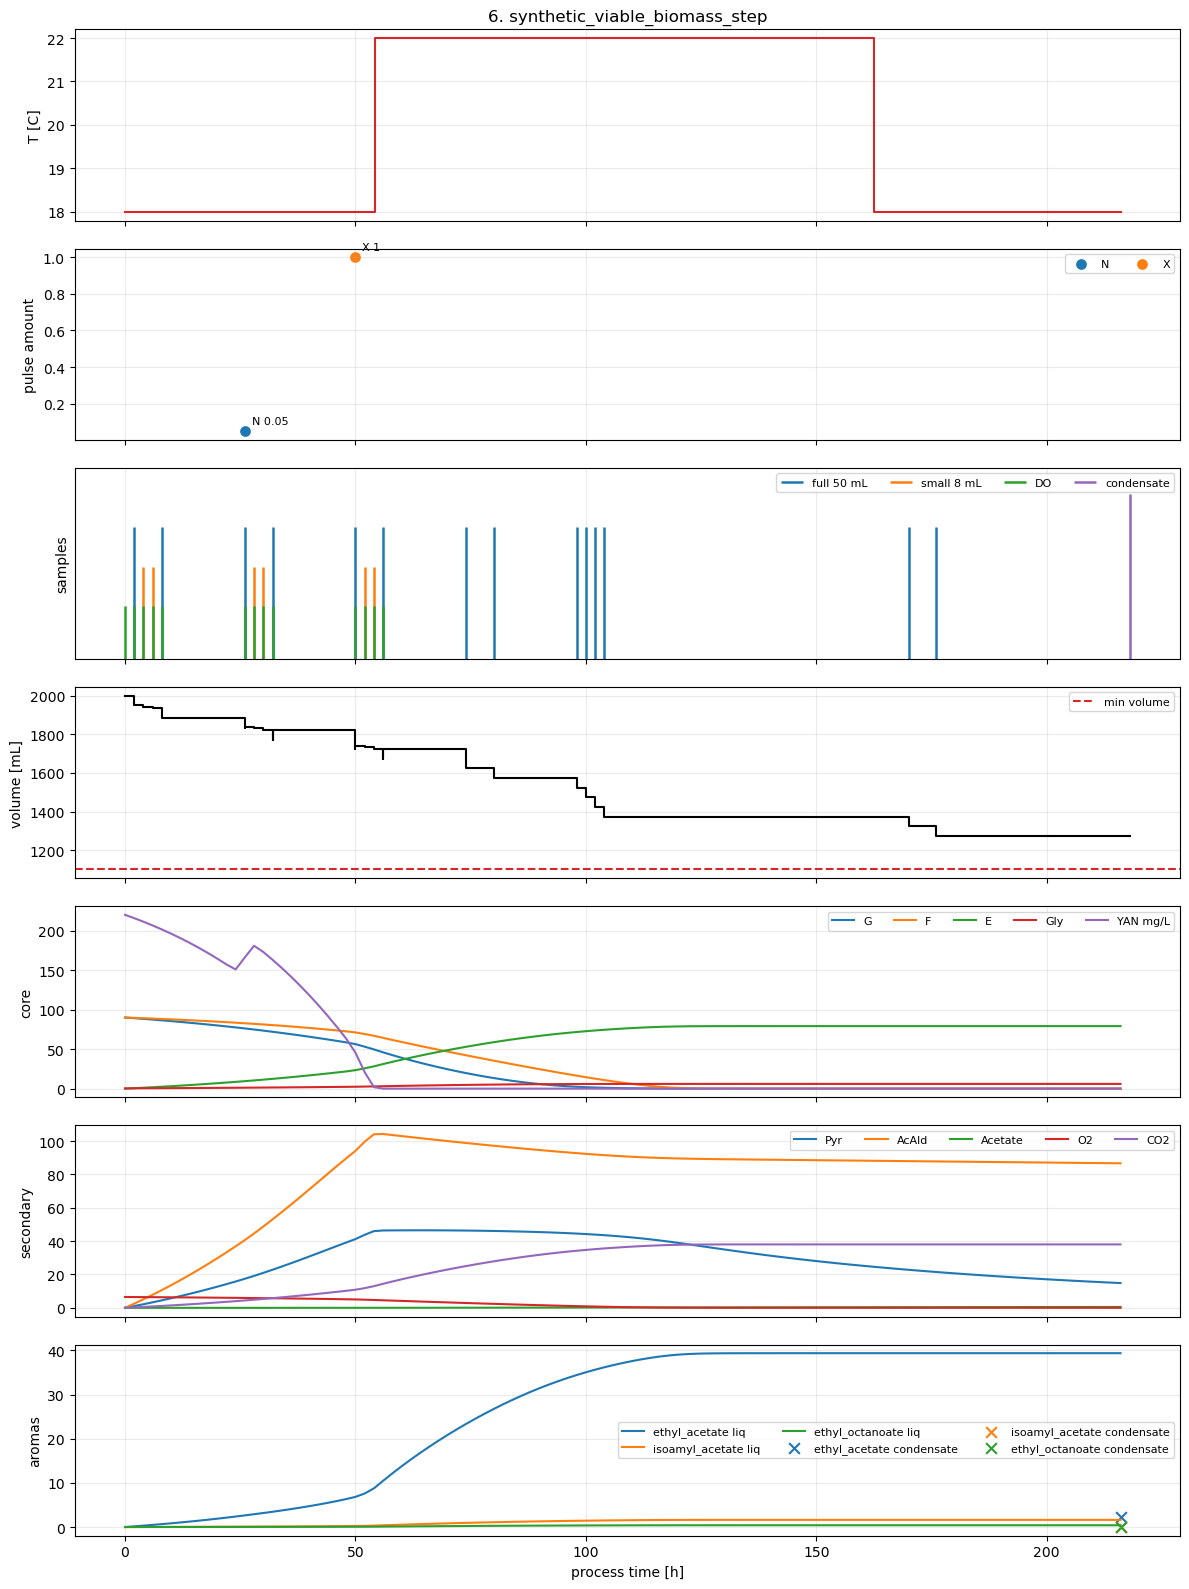

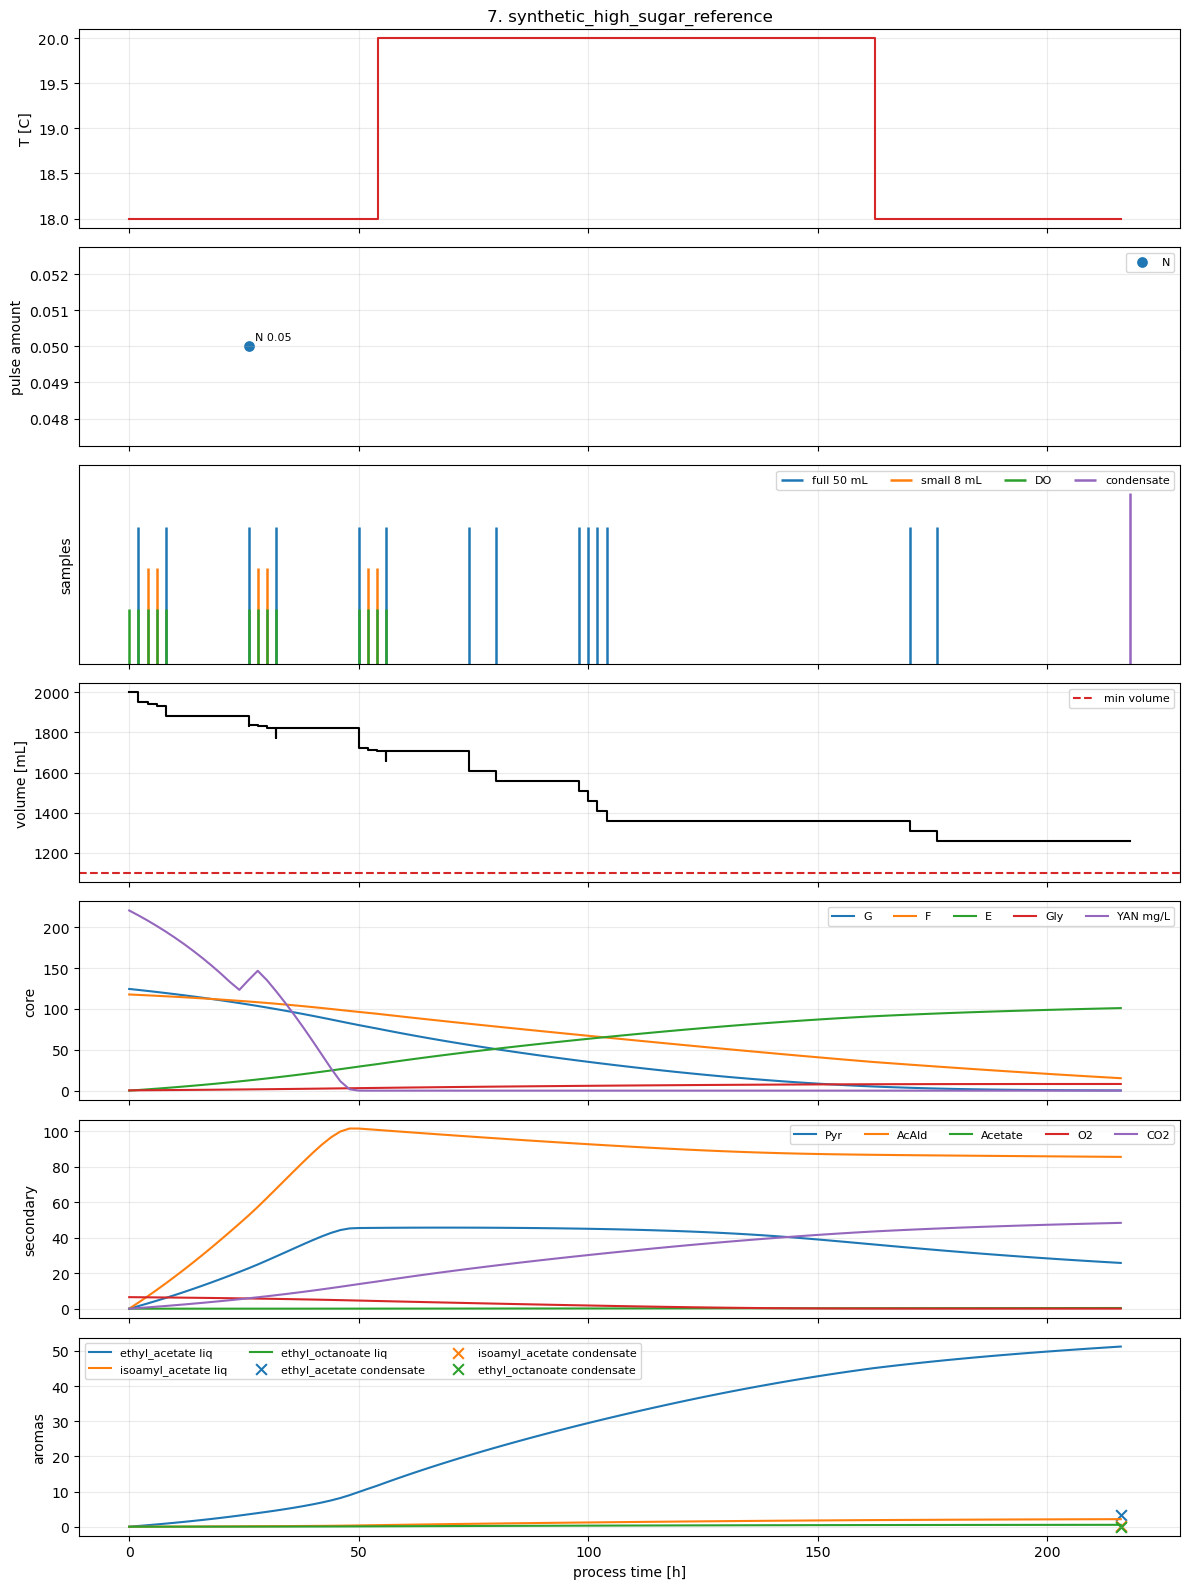

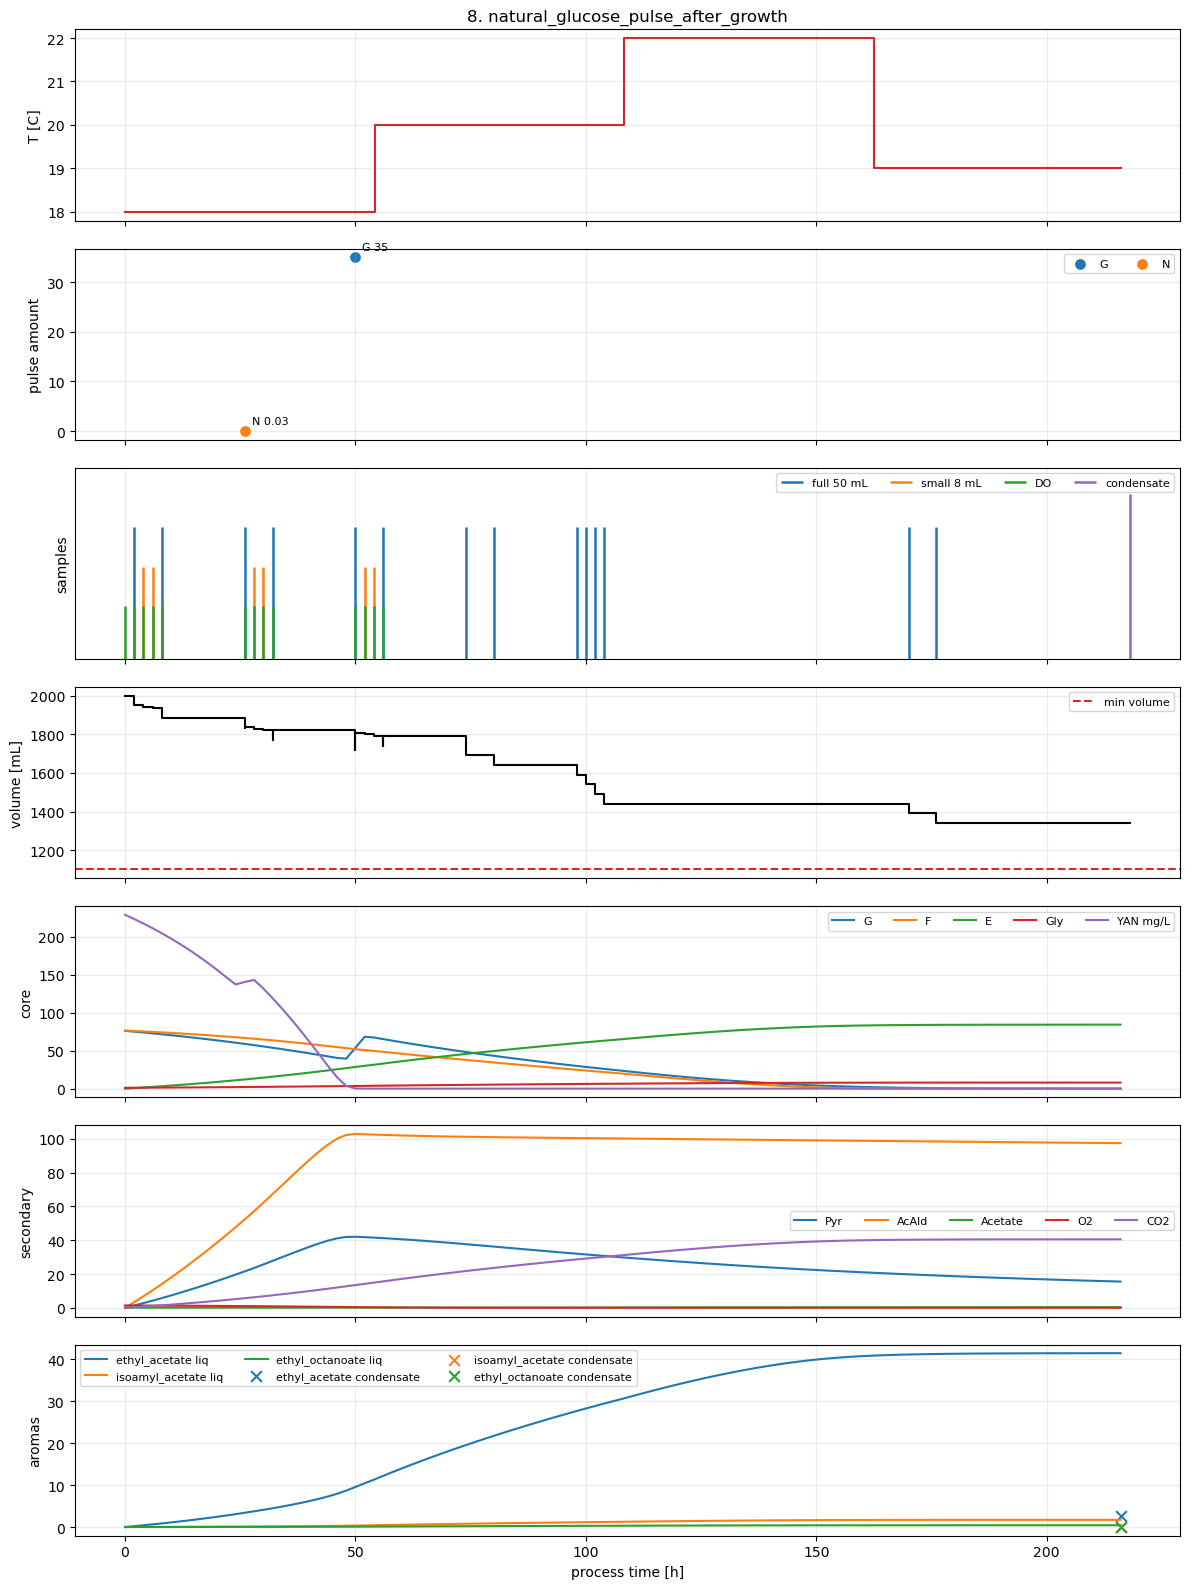

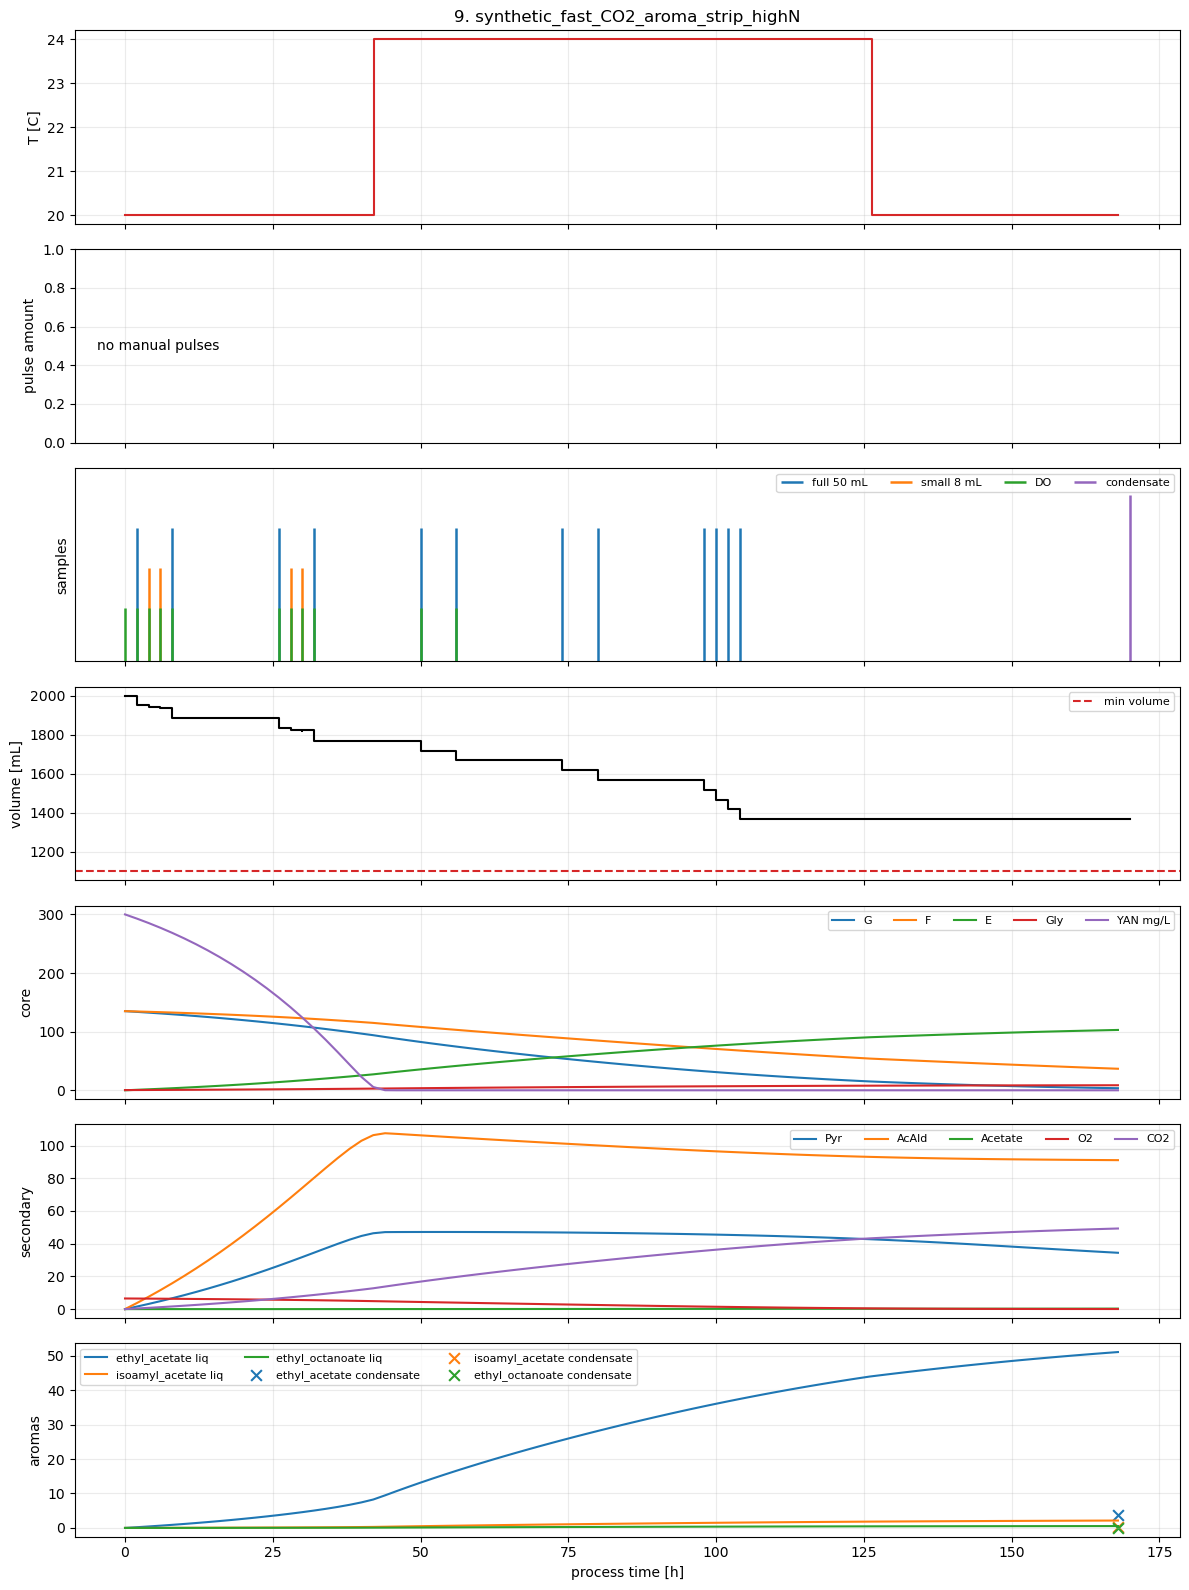

In [7]:
def _event_times(group, event):
    return group.loc[group["event"].eq(event), "relative_time_h"].astype(float).to_numpy()


def _plot_one(record):
    name = str(record["candidate"])
    order = int(record["campaign_order"])
    design = designs[name]
    group = schedule[schedule["candidate"].eq(name)].sort_values("relative_time_h").copy()
    sim = vc.simulate(design, theta, POLICY)
    t_grid = np.linspace(0.0, float(design.horizon_h), 400)

    fig, axes = plt.subplots(7, 1, figsize=(12, 16), sharex=True)

    axes[0].step(t_grid, [base.temperature_at(design, t) for t in t_grid], where="post", color="tab:red")
    axes[0].set_ylabel("T [C]")
    axes[0].set_title(f"{order}. {name}")

    pulse_rows = group[group["event"].eq("manual_pulse")]
    if pulse_rows.empty:
        axes[1].text(0.02, 0.5, "no manual pulses", transform=axes[1].transAxes, va="center")
    else:
        for channel, rows in pulse_rows.groupby("channel"):
            axes[1].scatter(rows["relative_time_h"], rows["amount"], label=channel, s=45)
            for _, row in rows.iterrows():
                axes[1].annotate(
                    f"{row['channel']} {float(row['amount']):g}",
                    (float(row["relative_time_h"]), float(row["amount"])),
                    textcoords="offset points",
                    xytext=(5, 5),
                    fontsize=8,
                )
        axes[1].legend(fontsize=8, ncol=5)
    axes[1].set_ylabel("pulse amount")

    markers = [
        ("full_liquid_sample", "tab:blue", 1.0, "full 50 mL"),
        ("small_liquid_sample", "tab:orange", 0.7, "small 8 mL"),
        ("DO_measurement", "tab:green", 0.4, "DO"),
        ("terminal_condensate_retrieval", "tab:purple", 1.25, "condensate"),
    ]
    for event, color, ymax, label in markers:
        times = _event_times(group, event)
        if len(times):
            axes[2].vlines(times, 0, ymax, colors=color, lw=1.8, label=label)
    axes[2].set_ylim(0, 1.45)
    axes[2].set_yticks([])
    axes[2].set_ylabel("samples")
    axes[2].legend(fontsize=8, ncol=4)

    axes[3].step(group["relative_time_h"], group["volume_after_ml"], where="post", color="black")
    axes[3].axhline(vc.MIN_FINAL_VOLUME_ML, color="tab:red", ls="--", label="min volume")
    axes[3].set_ylabel("volume [mL]")
    axes[3].legend(fontsize=8)

    if sim is not None:
        axes[4].plot(sim.core.index, sim.core["G"], label="G")
        axes[4].plot(sim.core.index, sim.core["F"], label="F")
        axes[4].plot(sim.core.index, sim.core["E"], label="E")
        axes[4].plot(sim.core.index, sim.core["Gly"], label="Gly")
        axes[4].plot(sim.core.index, sim.core["N"] * 1000.0, label="YAN mg/L")
        axes[4].set_ylabel("core")
        axes[4].legend(fontsize=8, ncol=5)

        for state in ("Pyr", "AcAld", "Acetate", "O2", "CO2"):
            axes[5].plot(sim.secondary.index, sim.secondary[state], label=state)
        axes[5].set_ylabel("secondary")
        axes[5].legend(fontsize=8, ncol=5)

        for species in joint.AROMA_SPECIES:
            axes[6].plot(sim.aromas_liq.index, sim.aromas_liq[species], label=f"{species} liq")
        for idx, species in enumerate(joint.AROMA_SPECIES):
            axes[6].scatter(
                [float(design.horizon_h)],
                [float(sim.aromas_cond[species])],
                marker="x",
                s=60,
                label=f"{species} condensate",
            )
        axes[6].set_ylabel("aromas")
        axes[6].legend(fontsize=8, ncol=3)
    else:
        axes[4].text(0.02, 0.5, "simulation failed", transform=axes[4].transAxes, va="center")

    for ax in axes:
        ax.grid(True, alpha=0.25)
    axes[-1].set_xlabel("process time [h]")
    fig.tight_layout()
    PLOT_DIR.mkdir(parents=True, exist_ok=True)
    out = PLOT_DIR / f"doe_{order:02d}.png"
    fig.savefig(out, dpi=170)
    return fig


for _, record in protocol.sort_values("campaign_order").iterrows():
    fig = _plot_one(record)
    plt.show()

## Expected Post-Campaign Estimability

This is the local FIM-based expectation after adding the selected volume-constrained campaign to the current prior. Interpret it as design guidance, not as a guarantee: after each lot, the model should be recalibrated and the next lots should be reviewed.

In [8]:
display(post_estimability)

,analysis,parameter,theta,std_log_approx,approx_95_multiplier,active_bound,classification
0,post_campaign_full14_small6,mu0,0.060170,0.004920,1.009690,False,well_estimated
1,post_campaign_full14_small6,qN,0.014609,0.005522,1.010883,False,well_estimated
2,post_campaign_full14_small6,betaG0,0.779854,0.016906,1.033691,False,well_estimated
3,post_campaign_full14_small6,betaF0,0.510897,0.028874,1.058225,False,well_estimated
4,post_campaign_full14_small6,qEG,1.537936,0.012362,1.024525,False,well_estimated
5,post_campaign_full14_small6,qEF,1.262713,0.018380,1.036682,False,well_estimated
6,post_campaign_full14_small6,iG,0.007367,0.037147,1.075524,False,well_estimated
7,post_campaign_full14_small6,iE,0.025862,0.023275,1.046675,False,well_estimated
8,post_campaign_full14_small6,Kd0,0.000669,0.026035,1.052353,False,well_estimated
9,post_campaign_full14_small6,gammaG0,0.097507,0.019126,1.038199,False,well_estimated


## Files Written By This Notebook

Per-fermentation overview plots were saved under:

`results/vc_doe_nb_plots/`

In [9]:
for path in sorted(PLOT_DIR.glob("doe_*.png")):
    print(path)

C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\pyomo-doe\fermentation_model\results\vc_doe_nb_plots\doe_01.png
C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\pyomo-doe\fermentation_model\results\vc_doe_nb_plots\doe_02.png
C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\pyomo-doe\fermentation_model\results\vc_doe_nb_plots\doe_03.png
C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\pyomo-doe\fermentation_model\results\vc_doe_nb_plots\doe_04.png
C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\pyomo-doe\fermentation_model\results\vc_doe_nb_plots\doe_05.png
C:\Users\ctorrealba\OneDrive - Viña Concha y Toro S.A\Documentos\Doctorado\Artículos\Artículo - Estimación_dFBA\pyomo-do